# Importaciones de librerías

In [24]:
# add libraries
import pandas as pd # para manipulación y anlálisis/for data manipulation and analysis
import numpy as np # para operaciones numéricas/ for numerical operations
import matplotlib.pyplot as plt # para visualización de datos usando charts/fors data visaulization using charts
import seaborn as sns # para visualización de datos estadísticos/for statistical data visualization
import math

# Lectura de datos

In [25]:
# 1. Cargar los datasets
# Asegúrate de que los nombres de los archivos coincidan exactamente con los que descargaste
df_academico = pd.read_csv('dataset_academico.csv')
df_psicosocial = pd.read_csv('dataset_psicosocial.csv')

# Mostrar las dimensiones iniciales para verificar
print(f"Filas y columnas del Dataset Académico: {df_academico.shape}")
print(f"Filas y columnas del Dataset Psicosocial: {df_psicosocial.shape}")

Filas y columnas del Dataset Académico: (3000, 17)
Filas y columnas del Dataset Psicosocial: (3000, 20)


In [26]:
# 2. Unir ambos datasets mediante la columna 'id_estudiante'
# Usamos how='inner' para asegurar que solo se unan los estudiantes que existan en ambos archivos
df_completo = pd.merge(df_academico, df_psicosocial, on='id_estudiante', how='inner')

# 3. Verificar el resultado de la unión
print(f"Filas y columnas del Dataset Completo (Unido): {df_completo.shape}")

# Mostrar las primeras 5 filas del dataset unido
df_completo.head()

Filas y columnas del Dataset Completo (Unido): (3000, 36)


,id_estudiante,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,...,nivel_autoestima,nivel_ansiedad,nivel_motivacion_escolar,apoyo_familiar_percibido,eventos_estresantes_recientes,relacion_con_companeros,horas_sueño_diarias,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa
0,3169,16.0,5,10.85,14.06,12.30,13.37,0,77.5,6,...,5.0,1,4,4,0,Regular,7.2,0,1,1
1,1163,15.0,3,18.63,14.59,16.66,17.37,0,100.0,1,...,3.0,2,5,3,0,Regular,7.9,0,0,0
2,2517,13.0,2,20.00,16.54,14.42,16.74,0,98.5,2,...,3.0,2,5,4,0,Regular,6.7,0,0,0
3,2318,13.0,1,16.91,19.40,19.70,18.24,1,95.4,1,...,5.0,2,3,3,0,Buena,5.2,0,1,0
4,1686,17.0,5,17.83,13.27,14.91,15.59,0,87.4,2,...,4.0,2,3,4,0,Buena,6.8,0,1,0


# EDA

In [27]:
df_completo.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id_estudiante                            3000 non-null   int64  
 1   edad                                     3000 non-null   float64
 2   grado                                    3000 non-null   int64  
 3   promedio_matematica                      3000 non-null   float64
 4   promedio_comunicacion                    3000 non-null   float64
 5   promedio_ciencias                        2910 non-null   float64
 6   promedio_general                         3000 non-null   float64
 7   num_cursos_desaprobados                  3000 non-null   int64  
 8   porcentaje_asistencia                    2940 non-null   float64
 9   num_tardanzas                            3000 non-null   int64  
 10  num_inasistencias_injustificadas         3000 non-null   in

In [28]:
df_completo.isnull().sum()

id_estudiante                                 0
edad                                          0
grado                                         0
promedio_matematica                           0
promedio_comunicacion                         0
promedio_ciencias                            90
promedio_general                              0
num_cursos_desaprobados                       0
porcentaje_asistencia                        60
num_tardanzas                                 0
num_inasistencias_injustificadas              0
tendencia_notas                             120
participacion_clase                           0
entrega_tareas                              150
repitio_grado                                 0
horas_estudio_semanal                       180
target                                        0
genero                                        0
estructura_familiar                           0
num_hermanos                                  0
nivel_socioeconomico                    

In [29]:
for col in df_completo.columns:

    if 'id_estudiante' in col.lower(): 
        continue
        
    print(f"\n{'='*60}")
    print(f"Columna: {col}")
    print(f"Cantidad de valores únicos: {df_completo[col].nunique()}")
    #print(df_completo[col].value_counts(dropna=False).to_string())


Columna: edad
Cantidad de valores únicos: 9

Columna: grado
Cantidad de valores únicos: 5

Columna: promedio_matematica
Cantidad de valores únicos: 1313

Columna: promedio_comunicacion
Cantidad de valores únicos: 1293

Columna: promedio_ciencias
Cantidad de valores únicos: 1298

Columna: promedio_general
Cantidad de valores únicos: 1248

Columna: num_cursos_desaprobados
Cantidad de valores únicos: 10

Columna: porcentaje_asistencia
Cantidad de valores únicos: 514

Columna: num_tardanzas
Cantidad de valores únicos: 23

Columna: num_inasistencias_injustificadas
Cantidad de valores únicos: 20

Columna: tendencia_notas
Cantidad de valores únicos: 3

Columna: participacion_clase
Cantidad de valores únicos: 3

Columna: entrega_tareas
Cantidad de valores únicos: 707

Columna: repitio_grado
Cantidad de valores únicos: 2

Columna: horas_estudio_semanal
Cantidad de valores únicos: 192

Columna: target
Cantidad de valores únicos: 3

Columna: genero
Cantidad de valores únicos: 3

Columna: estruct

## Análisis estadístico de variables numéricas y categóricas

In [30]:
# Configuración para que los gráficos se vean modernos y legibles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Librerías listas para el EDA.")

Librerías listas para el EDA.


In [31]:
# 1. Resumen de variables numéricas (Continuas y Discretas)
print("=== RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ===")
display(df_completo.describe().T) 
# NOTA ANALÍTICA: Observa aquí los mínimos y máximos. 
# Por ejemplo, verifica si los promedios están en escala 0-20 o 0-100, 
# y si las asistencias tienen sentido (mínimo 0, máximo 100).

=== RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
id_estudiante,3000.0,2500.500000,866.169729,1001.00,1750.7500,2500.500,3250.2500,4000.00
edad,3000.0,14.462667,1.550723,6.00,13.0000,14.000,16.0000,30.00
grado,3000.0,2.958333,1.412774,1.00,2.0000,3.000,4.0000,5.00
promedio_matematica,3000.0,12.209660,4.058927,0.00,9.2375,12.240,15.2125,20.00
promedio_comunicacion,3000.0,12.295623,4.087180,0.00,9.4000,12.355,15.4000,20.00
promedio_ciencias,2910.0,12.389969,4.126823,0.00,9.4800,12.490,15.5200,20.00
promedio_general,3000.0,12.312043,3.605354,2.14,9.6175,12.395,15.1600,20.00
num_cursos_desaprobados,3000.0,1.882000,1.768932,0.00,0.0000,2.000,3.0000,9.00
porcentaje_asistencia,2940.0,78.370748,12.408769,31.60,69.9000,78.700,87.7250,112.70
num_tardanzas,3000.0,4.870000,3.554431,0.00,2.0000,4.000,7.0000,57.00


Este cuadro revela que estamos trabajando con el sistema de calificación peruano (escala vigesimal de 0 a 20), pero también ha sacado a la luz valores atípicos (outliers) que tendremos que limpiar en el preprocesamiento:

- Asistencia imposible: La columna porcentaje_asistencia tiene un valor máximo de 112.70. Matemáticamente, nadie puede asistir más del 100% de las clases. Esto es un error de digitación en el dataset.
- Edades extremas: La edad mínima es de 6 años y la máxima de 30 años. Para estudiantes de secundaria (asumiendo grados del 1° al 5°), estos valores son inusuales y podrían sesgar el modelo.
- Horas de sueño dudosas: Hay un estudiante que registra 0.6 horas de sueño diarias (menos de 40 minutos), lo cual es biológicamente improbable.

In [32]:
# 2. Resumen de variables categóricas / texto
print("=== RESUMEN DE VARIABLES CATEGÓRICAS ===")
display(df_completo.describe(include=['object', 'str']).T)
# NOTA ANALÍTICA: Aquí vemos cuántas categorías únicas tiene cada variable 
# y cuál es la categoría más frecuente (top).

=== RESUMEN DE VARIABLES CATEGÓRICAS ===


,count,unique,top,freq
tendencia_notas,2880,3,Mejorando,1018
participacion_clase,3000,3,Media,1142
target,3000,3,Necesita_reforzamiento,1196
genero,3000,3,Masculino,1436
estructura_familiar,3000,4,Ambos padres,1611
nivel_socioeconomico,2880,4,Medio,1140
nivel_educativo_padres,2850,4,Secundaria,1245
relacion_con_companeros,2910,3,Regular,1254


No hay anomalías graves aquí. Observamos que la mayoría de los estudiantes están mejorando sus notas, tienen una participación media, pertenecen al género masculino, viven con ambos padres y tienen un nivel socioeconómico medio. Todo esto refleja un entorno demográfico bastante estándar.

## Análisis del target

Variable objetivo (target) es la columna llamada explícitamente target, la cual representa la situación o estado académico del estudiante.
Es una variable de tipo categórica nominal (multiclase) y está compuesta por exactamente 3 clases:
- Continua_estudiando
- Necesita_reforzamiento
- Suspendido

Distribución de la Variable Objetivo:
- Necesita_reforzamiento: 1196 estudiantes (39.87%)
- Continua_estudiando: 1195 estudiantes (39.83%)
- Suspendido: 609 estudiantes (20.30%)


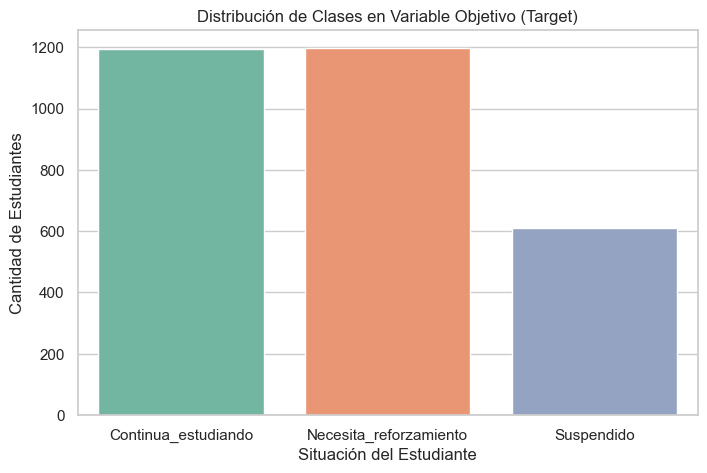

In [33]:
# Contar cuántos estudiantes hay en cada clase de la variable objetivo
target_counts = df_completo['target'].value_counts()
target_percentage = df_completo['target'].value_counts(normalize=True) * 100

print("Distribución de la Variable Objetivo:")
for clase, conteo, porc in zip(target_counts.index, target_counts.values, target_percentage.values):
    print(f"- {clase}: {conteo} estudiantes ({porc:.2f}%)")

# Graficar la distribución
plt.figure(figsize=(8, 5))
sns.countplot(data=df_completo, x='target', hue='target', palette='Set2', legend=False)
plt.title('Distribución de Clases en Variable Objetivo (Target)')
plt.xlabel('Situación del Estudiante')
plt.ylabel('Cantidad de Estudiantes')
plt.show()

# DECISIÓN BASADA EN ESTE PASO: 
# Si una clase tiene menos del 15%, en la fase de modelado consideraremos 
# usar pesos de clase (class_weight='balanced') en algoritmos como Random Forest o SVM.

- Continua_estudiando: 39.83%
- Necesita_reforzamiento: 39.87%
- Suspendido: 20.30%

Interpretación: Tu dataset está ligeramente desbalanceado, pero no es un caso extremo. La clase "Suspendido" es la minoritaria (apenas el 20%). Esto significa que cuando entrenemos el Random Forest y el SVM, será una buena práctica usar el hiperparámetro de pesos balanceados para evitar que el modelo ignore a los alumnos suspendidos.

## Validación de la dependencia estructural de datos faltantes

In [34]:
# Cruzamos la variable binaria 'trabaja_estudiante' con la presencia de nulos en 'horas_trabajo_semanal'
tabla_validacion = pd.crosstab(
    df_completo['trabaja_estudiante'], 
    df_completo['horas_trabajo_semanal'].isna(), 
    rownames=['¿Trabaja el estudiante? (0=No, 1=Sí)'], 
    colnames=['¿Las horas de trabajo son Nulas?']
)

print("Tabla de validación cruzada para Datos Faltantes:")
display(tabla_validacion)

# DECISIÓN ANALÍTICA:
# - Si los nulos (True) ocurren ÚNICAMENTE cuando trabaja_estudiante es 0, significa que 
#   es un nulo estructural. La decisión correcta de preprocesamiento NO será borrar filas,
#   sino imputar esos nulos con el valor '0' (ya que un estudiante que no trabaja, labora 0 horas).

Tabla de validación cruzada para Datos Faltantes:


¿Las horas de trabajo son Nulas?,False,True
"¿Trabaja el estudiante? (0=No, 1=Sí)",,
0,0,2210
1,790,0


- Hay exactamente 2210 estudiantes que dijeron "No" (0) en trabaja_estudiante y tienen valor nulo (True) en horas_trabajo_semanal.

- Hay 790 estudiantes que dijeron "Sí" (1) y no tienen valores nulos.
Interpretación: Estos no son datos perdidos al azar. Es una ausencia estructural. La solución directa en el preprocesamiento será rellenar esos 2210 espacios vacíos con un rotundo 0.

## Análisis de distribución de los promedios académicos

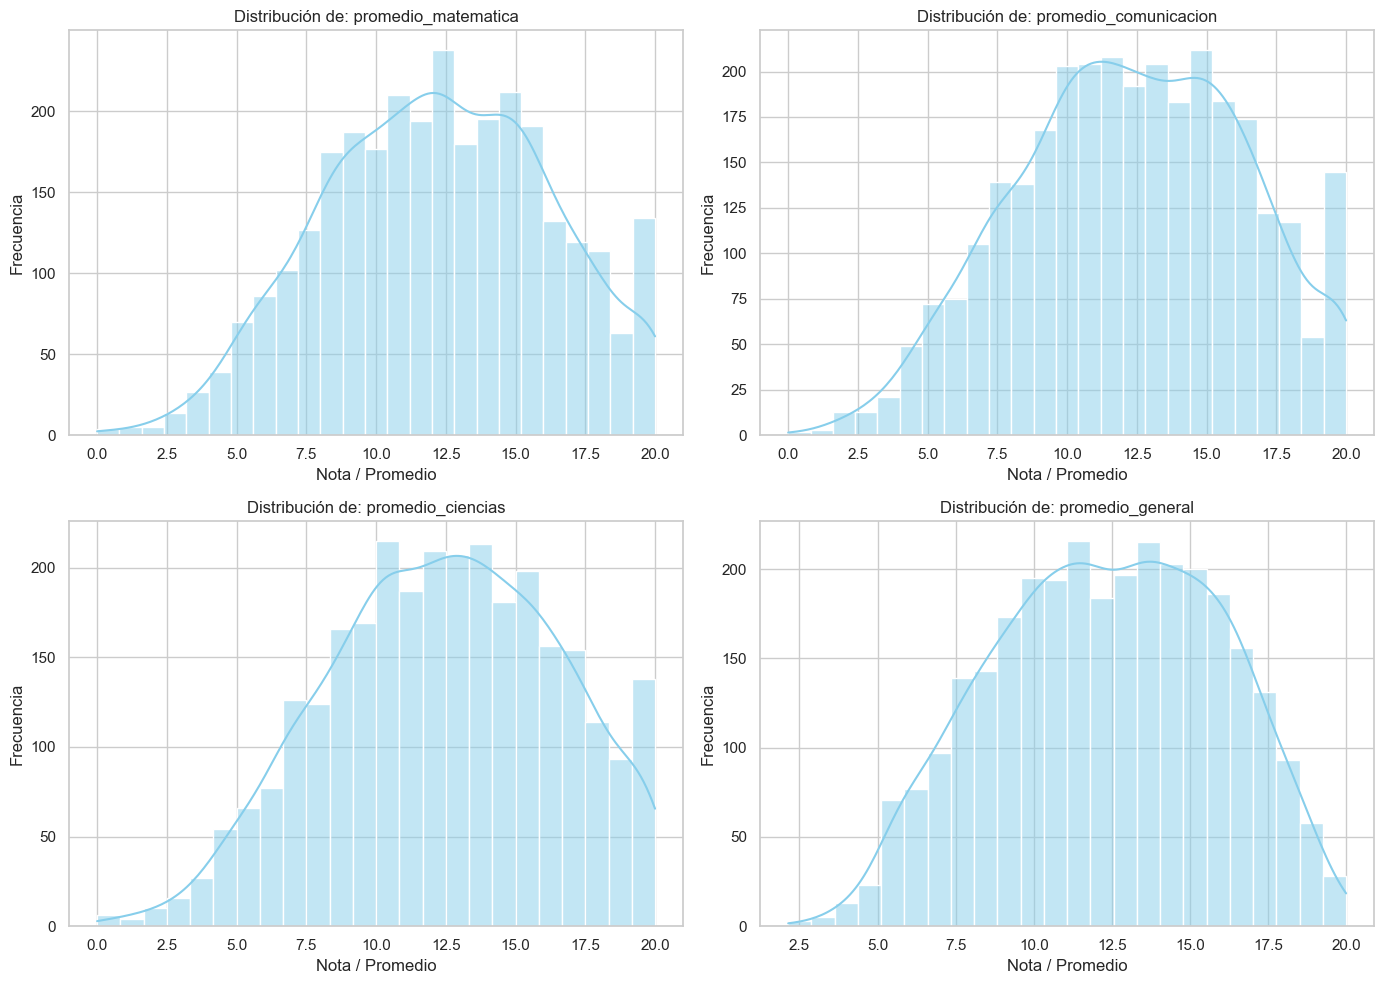

In [35]:
columnas_notas = ['promedio_matematica', 'promedio_comunicacion', 'promedio_ciencias', 'promedio_general']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_notas):
    # Usamos histplot con una línea de densidad (kde=True)
    sns.histplot(data=df_completo, x=col, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de: {col}')
    axes[i].set_xlabel('Nota / Promedio')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# DECISIÓN ANALÍTICA:
# Las distribuciones nos dicen si hay calificaciones atípicas (por ejemplo, notas de 0 que representen abandonos).
# El algoritmo SVM es sensible a las escalas de los datos, por lo que ver estas distribuciones 
# nos confirma que más adelante necesitaremos aplicar un escalador numérico (como StandardScaler).

Distribución de Notas: Las notas siguen una distribución casi normal (forma de campana), centradas entre 11 y 13.

## Análisis bivariado

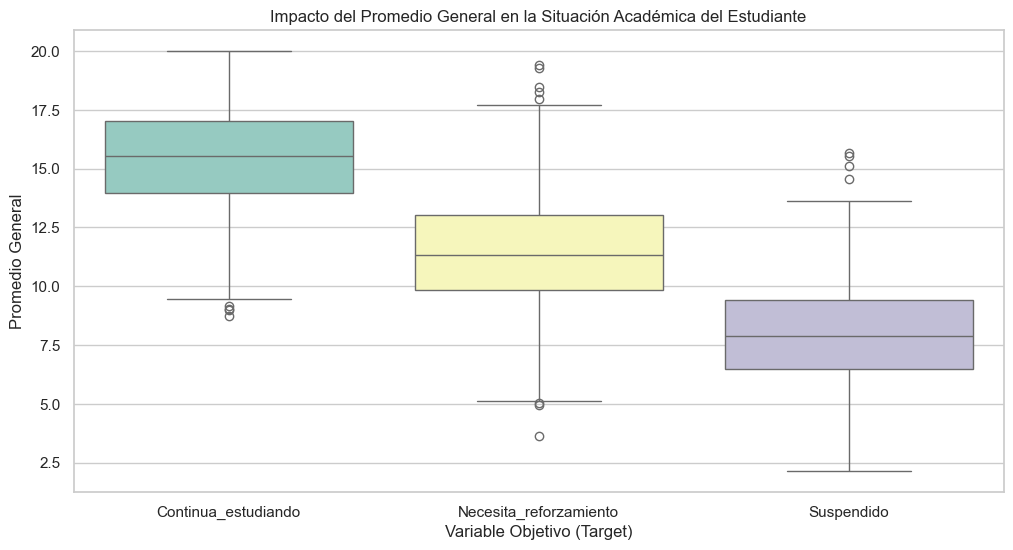

In [36]:
plt.figure(figsize=(12, 6))
# Comparamos el promedio general de los estudiantes según sus tres posibles estados objetivos
sns.boxplot(data=df_completo, x='target', y='promedio_general', hue='target', palette='Set3', legend=False)
plt.title('Impacto del Promedio General en la Situación Académica del Estudiante')
plt.xlabel('Variable Objetivo (Target)')
plt.ylabel('Promedio General')
plt.show()

# NOTA ANALÍTICA: Si las cajas están muy separadas entre sí, significa que el 'promedio_general' 
# será una variable con un peso altísimo para el Decision Tree y Random Forest.

Impacto del Promedio en el Target (Boxplots): Este es el gráfico más revelador. Las cajas están claramente separadas en escalones. Los que continúan estudiando tienen medianas cercanas a 15, los de reforzamiento rondan el 11.5, y los suspendidos caen por debajo de 8

## Matriz de correlación

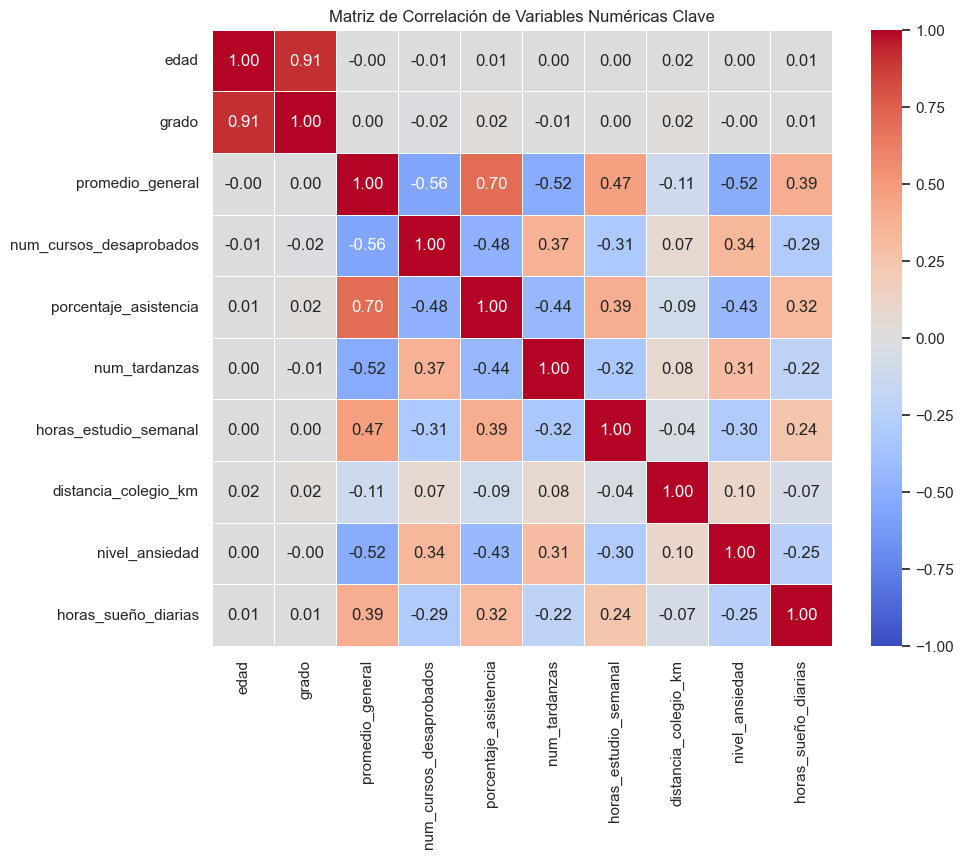

In [37]:
# Seleccionamos un subconjunto de variables numéricas críticas para no saturar el mapa de calor
variables_interes = [
    'edad', 'grado', 'promedio_general', 'num_cursos_desaprobados', 
    'porcentaje_asistencia', 'num_tardanzas', 'horas_estudio_semanal', 
    'distancia_colegio_km', 'nivel_ansiedad', 'horas_sueño_diarias'
]

matriz_corr = df_completo[variables_interes].corr()

# Graficar el Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas Clave')
plt.show()

# DECISIÓN ANALÍTICA:
# - Una correlación muy cercana a 1 o -1 entre dos variables independientes indica multicolinealidad.
# - Los árboles de decisión manejan bien esto, pero modelos lineales o basados en distancias (como SVM)
#   pueden verse afectados negativamente si dejamos variables redundantes.

Matriz de Correlación (Heatmap): * edad y grado tienen una correlación altísima de 0.91. Esto es lógico (a mayor grado, mayor edad), pero en Machine Learning se llama "multicolinealidad".

promedio_general y porcentaje_asistencia tienen una correlación fuerte positiva (0.70). Los que asisten más, sacan mejores notas.

# Preprocesamiento

## Tratamiento de nulos

El problema: Descubrimos que horas_trabajo_semanal tiene 2210 valores nulos, pero sabemos que pertenecen a estudiantes que marcaron 0 en trabaja_estudiante.

La técnica elegida: Imputación constante (rellenar con 0).
¿Por qué no otra técnica? Si usáramos la media o la mediana para rellenar estos vacíos (que es lo más común), le estaríamos asignando unas 20 horas de trabajo semanales a estudiantes que no trabajan. Eso destruiría la lógica del dataset.

In [38]:
# 1. Rellenar las horas de trabajo semanales con 0 para los que no trabajan
df_completo['horas_trabajo_semanal'] = df_completo['horas_trabajo_semanal'].fillna(0)

# Verificamos que ya no haya nulos en esa columna
print("Nulos en horas_trabajo_semanal:", df_completo['horas_trabajo_semanal'].isnull().sum())

Nulos en horas_trabajo_semanal: 0


## Tratamiento de Valores Atípicos

El problema: Encontramos que el porcentaje_asistencia llega hasta 112.70% (imposible) y horas_sueño_diarias baja a 0.6 horas (ilógico).

La técnica elegida: Capping o Truncamiento (establecer topes lógicos).
¿Por qué no otra técnica? La alternativa era eliminar esas filas (Delete). Es mejor corregir el error de digitación limitando la asistencia a un máximo de 100% y el sueño a un mínimo biológico razonable (por ejemplo, 3 horas).

In [39]:
# 2. Corregir asistencias mayores al 100%
# Todo valor mayor a 100 será reemplazado exactamente por 100
df_completo.loc[df_completo['porcentaje_asistencia'] > 100, 'porcentaje_asistencia'] = 100

# Corregir horas de sueño irreales (menores a 3 horas)
# Reemplazamos esos valores extremos con la mediana de sueño del grupo general
mediana_sueno = df_completo['horas_sueño_diarias'].median()
df_completo.loc[df_completo['horas_sueño_diarias'] < 3, 'horas_sueño_diarias'] = mediana_sueno

print("Outliers corregidos. Máxima asistencia actual:", df_completo['porcentaje_asistencia'].max())

Outliers corregidos. Máxima asistencia actual: 100.0


## Imputación de Nulos Estándar

El problema: Aún nos quedan valores faltantes en columnas como promedio_ciencias, tendencia_notas, nivel_socioeconomico, etc.

La técnica elegida: Imputación por la Mediana (para números) y por la Moda (para texto/categorías).
¿Por qué no otra técnica? * Para los números, elegimos la mediana en lugar de la media porque la media es muy sensible a valores extremos. Si un estudiante tiene un 0 en un curso, la media bajará drásticamente, pero la mediana se mantiene estable.

Para las categorías (texto), no podemos calcular matemáticas, así que usamos la moda (el valor que más se repite), asumiendo que el dato faltante probablemente pertenece a la mayoría.

In [40]:
# 3. Separar las columnas con nulos en numéricas y categóricas
columnas_con_nulos = df_completo.columns[df_completo.isnull().any()].tolist()

for col in columnas_con_nulos:
    if df_completo[col].dtype in ['float64', 'int64']:
        # Si es un número, imputar con la MEDIANA
        df_completo[col] = df_completo[col].fillna(df_completo[col].median())
    else:
        # Si es texto, imputar con la MODA (el primer valor de mode())
        df_completo[col] = df_completo[col].fillna(df_completo[col].mode()[0])

print("Total de valores nulos en todo el dataset después de la imputación:", df_completo.isnull().sum().sum())

Total de valores nulos en todo el dataset después de la imputación: 0


## Codificación de Variables Categóricas (Encoding)

El problema: Los algoritmos SVM, Random Forest y Decision Tree son fórmulas matemáticas. No entienden palabras como "Masculino" o "Mejorando"; necesitan números.

La técnica elegida: One-Hot Encoding para variables nominales y Label/Ordinal Encoding para variables con jerarquía y para el Target.
¿Por qué usamos dos técnicas distintas?

One-Hot Encoding (Variables Nominales): Para columnas como genero. Si le ponemos 1 a Femenino y 2 a Masculino, el algoritmo SVM (que mide distancias geométricas) pensará erróneamente que "Masculino vale el doble que Femenino". One-Hot crea columnas separadas con 0 y 1 para evitar esto.

Mapping/Ordinal Encoding: Para columnas como tendencia_notas. Aquí sí hay un orden lógico. "Empeorando" (0) es menor que "Estable" (1), y este es menor que "Mejorando" (2). Queremos que el modelo aprenda esa jerarquía.

In [41]:
# 4.1. Mapeo Manual (Ordinal) para mantener el orden jerárquico
mapa_tendencia = {'Empeorando': 0, 'Estable': 1, 'Mejorando': 2}
mapa_participacion = {'Baja': 0, 'Media': 1, 'Alta': 2}
mapa_socioeconomico = {'Bajo': 0, 'Medio-bajo': 1, 'Medio': 2, 'Alto': 3}
mapa_educativo = {'Sin estudios': 0, 'Primaria': 1, 'Secundaria': 2, 'Superior': 3}
mapa_companeros = {'Conflictiva': 0, 'Regular': 1, 'Buena': 2}

df_completo['tendencia_notas'] = df_completo['tendencia_notas'].map(mapa_tendencia)
df_completo['participacion_clase'] = df_completo['participacion_clase'].map(mapa_participacion)
df_completo['nivel_socioeconomico'] = df_completo['nivel_socioeconomico'].map(mapa_socioeconomico)
df_completo['nivel_educativo_padres'] = df_completo['nivel_educativo_padres'].map(mapa_educativo)
df_completo['relacion_con_companeros'] = df_completo['relacion_con_companeros'].map(mapa_companeros)

# 4.2. One-Hot Encoding para las variables nominales puras (sin orden)
# get_dummies transforma las categorías en columnas binarias (0 y 1)
df_completo = pd.get_dummies(df_completo, columns=['genero', 'estructura_familiar'], drop_first=True, dtype=int)

# 4.3. Codificar nuestro TARGET (variable a predecir) usando LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_completo['target'] = le.fit_transform(df_completo['target'])

# Guardamos las clases para saber qué número corresponde a qué categoría al final
clases_target = dict(zip(le.transform(le.classes_), le.classes_))
print("Mapeo del Target:", clases_target)

# Vista final para comprobar que todos nuestros datos ahora son números (numéricos o booleanos)
df_completo.head()

Mapeo del Target: {np.int64(0): 'Continua_estudiando', np.int64(1): 'Necesita_reforzamiento', np.int64(2): 'Suspendido'}


,id_estudiante,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,...,relacion_con_companeros,horas_sueño_diarias,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa,genero_Masculino,genero_Otro,estructura_familiar_Otros familiares,estructura_familiar_Tutor,estructura_familiar_Un solo padre
0,3169,16.0,5,10.85,14.06,12.30,13.37,0,77.5,6,...,1,7.2,0,1,1,0,0,1,0,0
1,1163,15.0,3,18.63,14.59,16.66,17.37,0,100.0,1,...,1,7.9,0,0,0,0,0,1,0,0
2,2517,13.0,2,20.00,16.54,14.42,16.74,0,98.5,2,...,1,6.7,0,0,0,0,1,0,0,0
3,2318,13.0,1,16.91,19.40,19.70,18.24,1,95.4,1,...,2,5.2,0,1,0,0,1,0,0,0
4,1686,17.0,5,17.83,13.27,14.91,15.59,0,87.4,2,...,2,6.8,0,1,0,0,0,1,0,0


In [43]:
df_completo.drop(columns=['id_estudiante'], inplace=True)

In [44]:
df_completo.head()

,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,num_inasistencias_injustificadas,...,relacion_con_companeros,horas_sueño_diarias,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa,genero_Masculino,genero_Otro,estructura_familiar_Otros familiares,estructura_familiar_Tutor,estructura_familiar_Un solo padre
0,16.0,5,10.85,14.06,12.30,13.37,0,77.5,6,1,...,1,7.2,0,1,1,0,0,1,0,0
1,15.0,3,18.63,14.59,16.66,17.37,0,100.0,1,0,...,1,7.9,0,0,0,0,0,1,0,0
2,13.0,2,20.00,16.54,14.42,16.74,0,98.5,2,2,...,1,6.7,0,0,0,0,1,0,0,0
3,13.0,1,16.91,19.40,19.70,18.24,1,95.4,1,5,...,2,5.2,0,1,0,0,1,0,0,0
4,17.0,5,17.83,13.27,14.91,15.59,0,87.4,2,2,...,2,6.8,0,1,0,0,0,1,0,0


# División de datos

In [45]:
# Separación de características y variable objetivo
X = df_completo.drop("target", axis=1)
y = df_completo["target"]

# Verificación de dimensiones iniciales
print(X.shape, y.shape)

from sklearn.model_selection import train_test_split

# División en Train y Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# Verificación de dimensiones finales de los conjuntos
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3000, 37) (3000,)
(2400, 37) (600, 37) (2400,) (600,)


In [53]:
# Inicializamos el diccionario para recolectar los scores de test para la gráfica final
resultados_test = {}

# Modelo ML

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

## SVM

In [47]:
model_svm = SVC(kernel='rbf', random_state=42)

## Random forest

In [56]:
from sklearn.ensemble import RandomForestClassifier

# Inicializamos el modelo Random Forest
model_rf = RandomForestClassifier(random_state=42)

## DECISION TREE

In [60]:
from sklearn.tree import DecisionTreeClassifier

# Inicializamos el modelo Decision Tree respetando el max_depth=4 de tu clase
model_dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Entrenamiento

## SVM

In [51]:
# Entrenamos el modelo con los datos correspondientes
model_svm.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


## Random forest

In [57]:
model_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## DECISION TREE

In [61]:
model_dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

# Resultados

## SVM

In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predicciones
y_pred_train_svm = model_svm.predict(X_train)
y_pred_svm = model_svm.predict(X_test)

# Formato exacto de impresión de tus capturas
print("Accuracy Train:", accuracy_score(y_train, y_pred_train_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nReporte:\n", classification_report(y_test, y_pred_svm))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_svm))

# Almacenamos el resultado para el gráfico final
resultados_test['SVM'] = accuracy_score(y_test, y_pred_svm)

Accuracy Train: 0.7825
Accuracy: 0.7733333333333333

Reporte:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85       239
           1       0.71      0.73      0.72       239
           2       0.74      0.71      0.72       122

    accuracy                           0.77       600
   macro avg       0.77      0.76      0.77       600
weighted avg       0.77      0.77      0.77       600


Matriz de confusión:
 [[202  36   1]
 [ 34 175  30]
 [  1  34  87]]


## random forest

In [58]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predicciones
y_pred_train_rf = model_rf.predict(X_train)
y_pred_rf = model_rf.predict(X_test)

# Formato exacto de impresión de tus capturas
print("Accuracy Train:", accuracy_score(y_train, y_pred_train_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nReporte:\n", classification_report(y_test, y_pred_rf))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_rf))

# Almacenamos el resultado para el gráfico final
resultados_test['Random Forest'] = accuracy_score(y_test, y_pred_rf)

Accuracy Train: 1.0
Accuracy: 0.78

Reporte:
               precision    recall  f1-score   support

           0       0.88      0.81      0.84       239
           1       0.71      0.75      0.73       239
           2       0.74      0.78      0.76       122

    accuracy                           0.78       600
   macro avg       0.78      0.78      0.78       600
weighted avg       0.79      0.78      0.78       600


Matriz de confusión:
 [[193  46   0]
 [ 26 180  33]
 [  0  27  95]]


## DECISION TREE

In [62]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predicciones
y_pred_train_dt = model_dt.predict(X_train)
y_pred_dt = model_dt.predict(X_test)

# Formato exacto de impresión de tus capturas
print("Accuracy Train:", accuracy_score(y_train, y_pred_train_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nReporte:\n", classification_report(y_test, y_pred_dt))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_dt))

# Almacenamos el resultado para el gráfico final
resultados_test['Decision Tree'] = accuracy_score(y_test, y_pred_dt)

Accuracy Train: 0.7591666666666667
Accuracy: 0.735

Reporte:
               precision    recall  f1-score   support

           0       0.81      0.84      0.83       239
           1       0.66      0.70      0.68       239
           2       0.73      0.59      0.65       122

    accuracy                           0.73       600
   macro avg       0.73      0.71      0.72       600
weighted avg       0.74      0.73      0.73       600


Matriz de confusión:
 [[201  38   0]
 [ 44 168  27]
 [  2  48  72]]


# Cross Validation

## SVM

In [55]:
from sklearn.model_selection import cross_val_score

# Validación cruzada exacta como tu ejemplo
scores_svm = cross_val_score(model_svm, X_train, y_train, cv=5, scoring='accuracy')
print("cv promedio accuracy:", scores_svm.mean())

cv promedio accuracy: 0.7787499999999999


## ramdom forest

In [59]:
from sklearn.model_selection import cross_val_score

# Validación cruzada exacta como tu ejemplo
scores_rf = cross_val_score(model_rf, X_train, y_train, cv=5, scoring='accuracy')
print("cv promedio accuracy:", scores_rf.mean())

cv promedio accuracy: 0.775


## DECISION TREE

In [63]:
from sklearn.model_selection import cross_val_score

# Validación cruzada exacta como tu ejemplo
scores_dt = cross_val_score(model_dt, X_train, y_train, cv=5, scoring='accuracy')
print("cv promedio accuracy:", scores_dt.mean())

cv promedio accuracy: 0.7291666666666667


# Comparación de resultados entre modelos

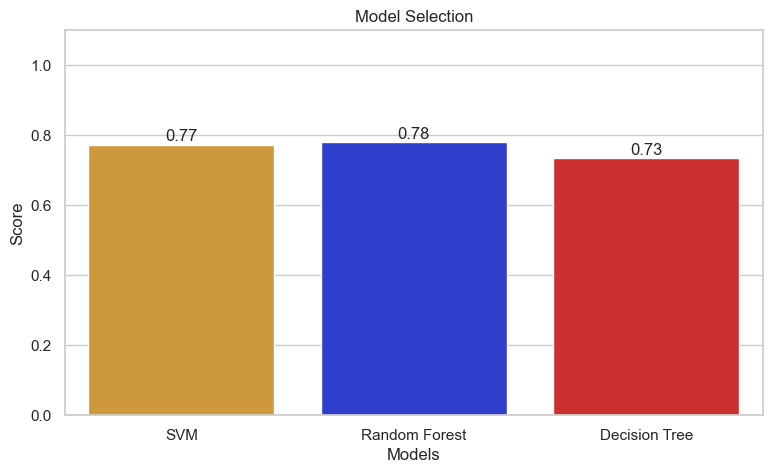

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# Tomamos las métricas recolectadas de las celdas anteriores
nombres_modelos = list(resultados_test.keys())
puntuaciones_modelos = list(resultados_test.values())

# Colores exactos de tu barra de ejemplo (Ocre, Azul, Rojo)
colores = ['#e69f24', '#152ae6', '#e61515']

ax = sns.barplot(
    x=nombres_modelos, 
    y=puntuaciones_modelos, 
    palette=colores, 
    hue=nombres_modelos, 
    legend=False
)

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Selection")
plt.ylim(0, 1.1)

# Añadir las etiquetas numéricas flotando sobre las barras
for p in ax.patches:
    ax.text(
        x=p.get_x() + p.get_width() / 2.,
        y=p.get_height() + 0.01,
        s='{:.2f}'.format(p.get_height()),
        ha='center'
    )

plt.show()

#  Descarga csv

In [65]:
# Guardamos el dataframe preprocesado y escalado en un nuevo archivo CSV
df_completo.to_csv("dataset_preprocesado.csv", index=False)

print("¡El dataset preprocesado se ha guardado con éxito como 'dataset_preprocesado.csv'!")

¡El dataset preprocesado se ha guardado con éxito como 'dataset_preprocesado.csv'!
